<h1>Trabalho 2 de ARQ - G13</h1>

<h1>Atividade 02 - melhorar o desempenho de RP em conjunto de dados existentes</h1>
<p>A atividade 02 visa trabalhar com um conjunto de dados pré-construído, onde as opções que o desenvolvedor tem, são de aplicar as técnicas de pré-processamento abaixo relacionadas:</p>
<ul><li>Seleção</li>
<li>Limpeza</li>
<li>Codificação</li>
<li>Enriquecimento</li>
<li>Normalização</li>
<li>Construção de Atributos</li>
<li>Correção de Prevalência</li>
<li>Partição do Conjunto de Dados</li>
</ul>
<p>Busque uma base de dados na UCI Machine Learning que seja indicada para problemas de classificação. (<a target="_blank" href="https://archive.ics.uci.edu/datasets">https://archive.ics.uci.edu/datasets</a>)</p>



<p>Nossa opção foi pela base "Adult Census Income", cujo objetivo é predizer se o valor de income é maior que 50k</p>
<p>O Dataset "Adult" da UCI, também conhecido como "Census Income Dataset", é largamente utilizado para tarefas de classificação para predizer se a soma de valores recebidos anualmente superam $50,000.00 baseado nos atributos demográficos e de emprego. Ele possui 14 atributos (features), tanto categóricas como numéricas, e requer pré-processamento e seleção de atributos para otimizar o desempenho do modelo.</p>
<p>O Dataset possui os seguinte atributos:</p>

- Numéricos: age, fnlwgt, education-num, capital-gain, capital-loss e hours-per-week 
   
- Categóricos: workclass, education, marital-status, occupation, relationship, race, sex e native-country

<p>A variável target é income, que pode assumir dois valores: '<=50K' ou '>50K'.</p>

## Parâmetros globais e carregamento das bibliotecas

In [65]:
# Hyperparametros
RAND_STATE = 13 # em homenagem ao Grupo!!
TEST_SIZE = 0.2 # 20% do Dataset para teste
FIG_SIZE = (8,5) # Tamanho das figuras

In [66]:
#  Bibliotecas básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para o modelo e avaliação
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
#from sklearn.linear_model import LogisticRegression
from sklearn import svm

# Configuração de exibição
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (8,6)


## Carregamento do Dataset

In [67]:
from ucimlrepo import fetch_ucirepo

  
# fetch dataset
try: 
    # tenda baixar da rede
    adult = fetch_ucirepo(id=2)
    
    # dados como um Dataframe Pandas
    df = pd.concat([adult.data.features, adult.data.targets], axis=1, ignore_index=False)

    # remove ponto final da coluna income ##bug##
    df["income"] = df["income"].str.replace('.', '', regex=False)

    # informação sobre as variáveis 
    display(adult.variables) 

except ConnectionError:
    # usa copia local
    import zipfile
    print("Usando copia local")
    
    colunas = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
    ]

    with zipfile.ZipFile("adult.zip") as z:
        with z.open("adult.data") as f:
            train = pd.read_csv(
            f,
            header=None,
            names=colunas,
            na_values="?",
            skipinitialspace=True
            )
        with z.open("adult.test") as f:
            test = pd.read_csv(
            f,
            header=None,
            names=colunas,
            na_values="?",
            skipinitialspace=True
            )
    df = pd.concat([train, test], axis=0, ignore_index=False)
# end of Except

# remove ponto final da coluna income ##bug##
df["income"] = df["income"].str.replace('.', '', regex=False)

# garantir que a coluna 'age' seja tratada como número (bug quando usa a cópia local)
df["age"] = pd.to_numeric(df["age"], errors="coerce")

Usando copia local


## Resumo dos dados

In [68]:
print("Shape:", df.shape)
df.info()
df.describe().style.background_gradient(cmap='Reds')

Shape: (48843, 15)
<class 'pandas.DataFrame'>
Index: 48843 entries, 0 to 16281
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  float64
 1   workclass       46043 non-null  str    
 2   fnlwgt          48842 non-null  float64
 3   education       48842 non-null  str    
 4   education-num   48842 non-null  float64
 5   marital-status  48842 non-null  str    
 6   occupation      46033 non-null  str    
 7   relationship    48842 non-null  str    
 8   race            48842 non-null  str    
 9   sex             48842 non-null  str    
 10  capital-gain    48842 non-null  float64
 11  capital-loss    48842 non-null  float64
 12  hours-per-week  48842 non-null  float64
 13  native-country  47985 non-null  str    
 14  income          48842 non-null  str    
dtypes: float64(6), str(9)
memory usage: 6.0 MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,189664.134597,10.078089,1079.067626,87.502314,40.422382
std,13.710510,105604.025423,2.570973,7452.019058,403.004552,12.391444
min,17.000000,12285.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,117550.500000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,178144.500000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,237642.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,1490400.000000,16.000000,99999.000000,4356.000000,99.000000


## Limpeza dos dados

In [69]:
print(f'\nDimensões do Dataset: {df.shape[0]} linhas x {df.shape[1]} colunas\n')


Dimensões do Dataset: 48843 linhas x 15 colunas



In [70]:
# No dataset original valores faltantes foram substituídos por '?'
df = df.replace("?", np.nan)

In [71]:
print("=== Valores faltantes por coluna ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores Faltantes': missing, 'Percentual (%)': missing_pct})
print(missing_df[missing_df['Valores Faltantes'] > 0])

=== Valores faltantes por coluna ===
                Valores Faltantes  Percentual (%)
age                             1            0.00
workclass                    2800            5.73
fnlwgt                          1            0.00
education                       1            0.00
education-num                   1            0.00
marital-status                  1            0.00
occupation                   2810            5.75
relationship                    1            0.00
race                            1            0.00
sex                             1            0.00
capital-gain                    1            0.00
capital-loss                    1            0.00
hours-per-week                  1            0.00
native-country                858            1.76
income                          1            0.00


In [72]:
# Substitui valores faltantes pela moda ou média
for col in df.columns:
    if df[col].dtype == "str":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [73]:
# Verifica se existe linhas duplicadas
print(f'=== Verificação de Dados Duplicados ===')

duplicadas = df.duplicated().sum()
print(f'Total de linhas duplicadas: {duplicadas:,}')

# remoção de linhas duplicadas
if duplicadas > 0:
  print("\nIndice das linhas duplicadas:")
  print(df[df.duplicated(keep=False)].index.values)
  df = df.drop_duplicates()
  print(f'\nLinhas após remoção de duplicatas: {len(df):}')
else:
  print('\nNenhuma linha duplicata encontrada. Nenhuma ação necessária.')

=== Verificação de Dados Duplicados ===
Total de linhas duplicadas: 53

Indice das linhas duplicadas:
[ 2195  2303  3118  3445  3917  4325  4767  4881  4940  5104  5579  5805
  5842  6990  7053  7920  8080  8679  8908  9171  9371  9841 10094 10367
 11631 11965 13084 14581 14690 15059 15189 16297 16846 16975 17040 17673
 17867 17916 18555 18698 19567 20486 20567 20883 21103 21318 21490 21875
 21974 22249 22300 22367 22494 24667 25624 25684 25872 26313 27920 28230
 28522 28846 29157 30345 30384 30698 30845 31993 32404   489   865  1320
  1669  1855  1864  3901  4153  4859  5079  5783  5908  6433  6457  7022
  7351  8117  9250  9826 10827 10924 11190 11213 11747 12489 13505 13849
 14154 14309 14399 14488 14839 15324 15961]

Linhas após remoção de duplicatas: 48790


## Análise exploratória de dados

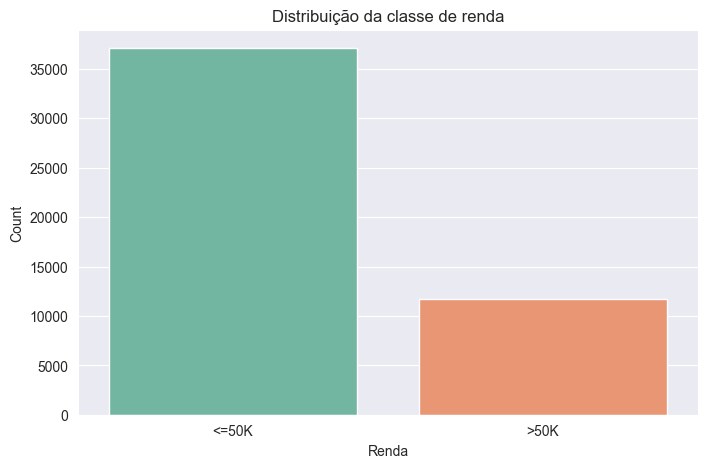

In [74]:
plt.figure(figsize=FIG_SIZE)
sns.countplot(data=df, x="income", hue="income", palette="Set2")
plt.title("Distribuição da classe de renda")
plt.xlabel("Renda")
plt.ylabel("Count")
plt.show()

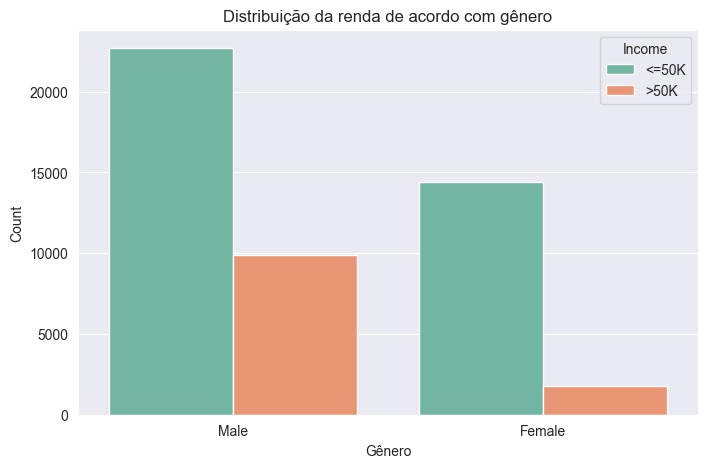

In [75]:
plt.figure(figsize=FIG_SIZE)
sns.countplot(data=df, x="sex", hue="income", palette="Set2")
plt.title("Distribuição da renda de acordo com gênero")
plt.xlabel("Gênero")
plt.ylabel("Count")
plt.legend(title="Income")
plt.show()

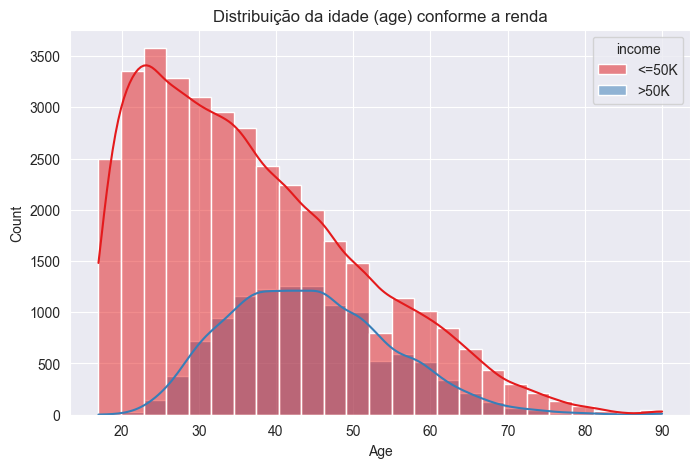

In [76]:
plt.figure(figsize=FIG_SIZE)
sns.histplot(data=df, x="age", hue="income", bins=25, palette="Set1", kde=True)
plt.title("Distribuição da idade (age) conforme a renda")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

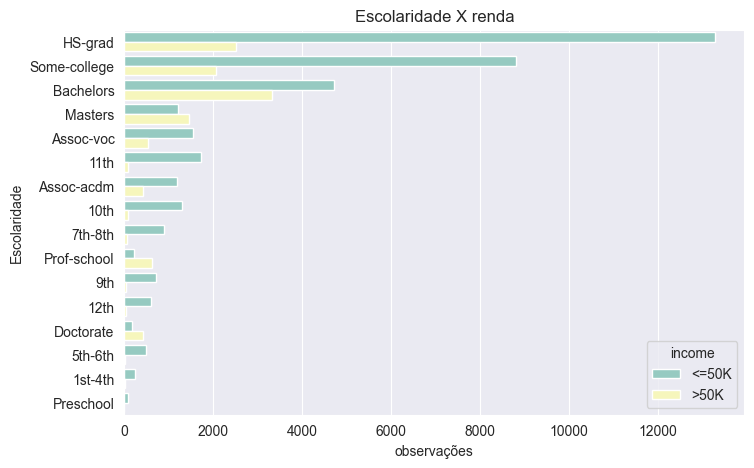

In [77]:
plt.figure(figsize=FIG_SIZE)
order = df["education"].value_counts().index
sns.countplot(data=df, y="education", order=order, hue="income", palette="Set3")
plt.title("Escolaridade X renda")
plt.xlabel("observações")
plt.ylabel("Escolaridade")
plt.show()

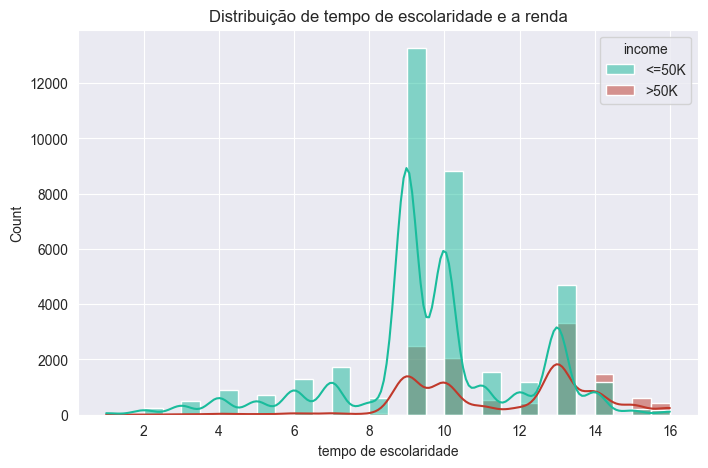

In [78]:
plt.figure(figsize=FIG_SIZE)
sns.histplot(
    data=df,
    x="education-num",
    hue="income",
    bins=30,
    kde=True,
    palette=["#1abc9c", "#c0392b"]
)

plt.title("Distribuição de tempo de escolaridade e a renda")
plt.xlabel("tempo de escolaridade")
plt.show()

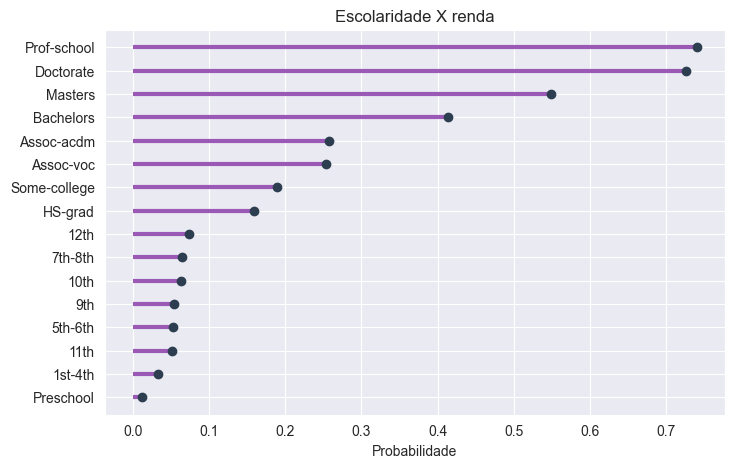

In [79]:
edu_income = (
    df.groupby("education")["income"]
    .apply(lambda x: (x == ">50K").mean())
    .sort_values()
)

plt.figure(figsize=FIG_SIZE)
plt.hlines(
    y=edu_income.index,
    xmin=0,
    xmax=edu_income.values,
    color="#9b59b6",
    linewidth=3
)
plt.plot(
    edu_income.values,
    edu_income.index,
    "o",
    color="#2c3e50"
)

plt.title("Escolaridade X renda")
plt.xlabel("Probabilidade")
plt.show()

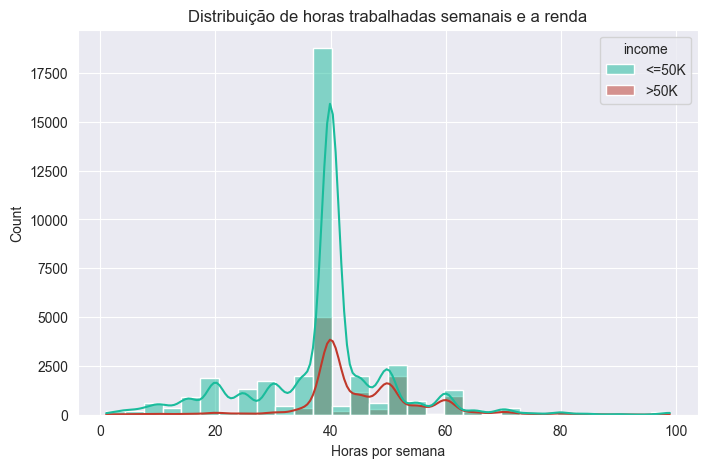

In [80]:
plt.figure(figsize=FIG_SIZE)
sns.histplot(
    data=df,
    x="hours-per-week",
    hue="income",
    bins=30,
    kde=True,
    palette=["#1abc9c", "#c0392b"]
)

plt.title("Distribuição de horas trabalhadas semanais e a renda")
plt.xlabel("Horas por semana")
plt.show()

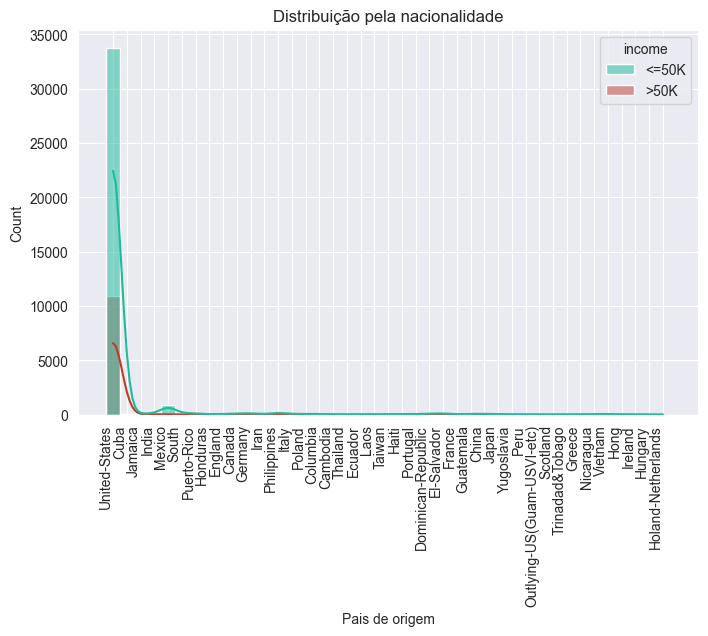

In [81]:
plt.figure(figsize=FIG_SIZE)
sns.histplot(
    data=df,
    x="native-country",
    hue="income",
    bins=30,
    kde=True,
    palette=["#1abc9c", "#c0392b"]
)

plt.title("Distribuição pela nacionalidade")
plt.xticks(rotation=90, ha='right')
plt.xlabel("Pais de origem")
plt.show()

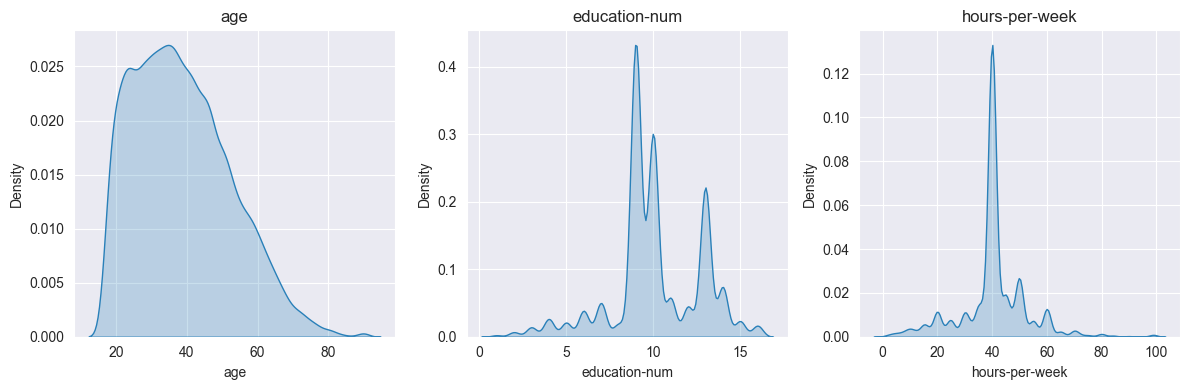

In [82]:
num_features = ["age", "education-num", "hours-per-week"]

plt.figure(figsize=(12,4))
for i, col in enumerate(num_features, 1):
    plt.subplot(1,3,i)
    sns.kdeplot(df[col], fill=True, color="#2980b9")
    plt.title(col)

plt.tight_layout()
plt.show()

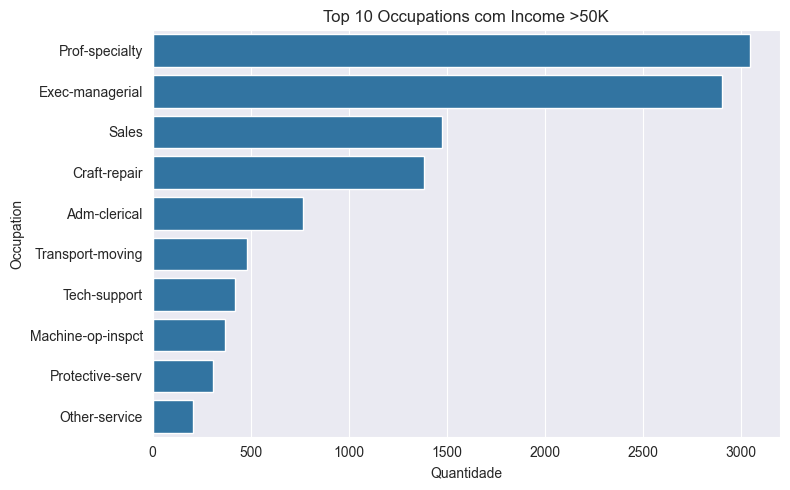

In [83]:
# Filtrar income >50K
df_high_income = df[df['income'] == '>50K']

# Contar occupations
top_occupations = (
    df_high_income['occupation']
    .value_counts()
    .head(10)
)

# Plot
plt.figure(figsize=FIG_SIZE)

sns.barplot(
    x=top_occupations.values,
    y=top_occupations.index
)

plt.title("Top 10 Occupations com Income >50K")
plt.xlabel("Quantidade")
plt.ylabel("Occupation")

plt.tight_layout()
plt.show()

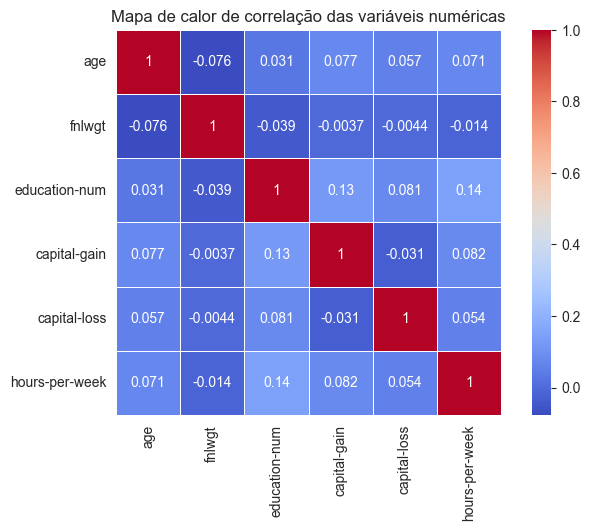

In [84]:
num_cols = df.select_dtypes(include="number").columns.tolist()

corr = df[num_cols].corr()

plt.figure(figsize=FIG_SIZE)
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Mapa de calor de correlação das variáveis numéricas")
plt.show()

## Redução de dimensionalidade

In [85]:
# vamos remover 'fnlwgt' e 'capital-loss' do dataset
df = df.drop(['fnlwgt', 'capital-loss'], axis=1)

In [86]:
# A coluna 'education' pode ser removida em favor da coluna 'education_num' que representa o número de anos de educação
df = df.drop(['education'], axis=1)

## Análise das variáveis categóricas

In [87]:
# Verifica a quantidades de classes das variáveis categóricas
df.select_dtypes(include="str").nunique().sort_values(ascending=False)

native-country    41
occupation        14
workclass          8
marital-status     7
relationship       6
race               5
sex                2
income             2
dtype: int64

In [88]:
# Verifica a cardinalidade de 'native-country' pois é a variável com maior número de classes
freq = df['native-country'].value_counts()
print(freq)

native-country
United-States                 44648
Mexico                          943
Philippines                     294
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Poland                           87
Guatemala                        86
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru                             46
Ecuador      

In [89]:
# Com a predominância de uma classe, vamos converter em apenas duas classes

# obter a classe dominante
dominante = df['native-country'].value_counts().idxmax()

# converte para binário
df['native-country'] = (df['native-country'] == dominante).astype(int)

In [90]:
# Vamos verificar a distribuição de classes em 'occupation'
freq = df['occupation'].value_counts()
print(freq)

occupation
Prof-specialty       8970
Craft-repair         6102
Exec-managerial      6082
Adm-clerical         5606
Sales                5501
Other-service        4919
Machine-op-inspct    3017
Transport-moving     2355
Handlers-cleaners    2071
Farming-fishing      1485
Tech-support         1445
Protective-serv       982
Priv-house-serv       240
Armed-Forces           15
Name: count, dtype: int64


In [91]:
# Vamos tratar como Other-service, todas as classes abaixo de 5000
rare = freq[freq < 5000].index

df["occupation"] = (
    df["occupation"]
    .replace(rare, "Other-service")
)

In [92]:
# Verifica a quantidades de classes das colunas descritivas remanescentes
df.select_dtypes(include="str").nunique().sort_values(ascending=False)

workclass         8
marital-status    7
occupation        6
relationship      6
race              5
sex               2
income            2
dtype: int64

In [93]:
# Converte as colunas onde os valores só possuem duas classes
# df['sex'] = df['sex'].map({
#     "Male": 1,
#     "Female": 0
# }).astype(int)

df['income'] = df['income'].map({
    "<=50K": 0,
    ">50K": 1
}).astype(int)

## Separação de Features e Target

In [94]:
# Separar features & target
X = df.drop("income", axis=1)

# Converte target em binário
y = df["income"]

# Identifica features numéricas e categóricas
num_cols = X.select_dtypes(exclude=["str"]).columns
cat_cols = X.select_dtypes(include=["str"]).columns


## Divisão em Treino e Teste

In [95]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RAND_STATE)

## Modelo (SVM)

In [96]:
# Algoritmo escolhido foi o SVM

cat_transform = OneHotEncoder(handle_unknown="ignore")
preprocess = ColumnTransformer([
    ("categorical", cat_transform, cat_cols)],
    remainder="passthrough"
)

# Modelo sem padronização do dados
model = Pipeline([
    ("preprocess", preprocess),
    ("model", svm.SVC())
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

## Modelo sem a padronização

In [97]:
# predição com os mesmos dados usados para treinar
y_pred_train = model.predict(X_train)

print('Matriz de confusão - com os dados ORIGINAIS usados no TREINAMENTO')
cm_orig_train = confusion_matrix(y_train, y_pred_train)
print(cm_orig_train)
print(classification_report(y_train, y_pred_train))

# predição com os mesmos dados usados para testar
y_pred_teste = model.predict(X_test)

print('Matriz de confusão - com os dados ORIGINAIS usados para TESTE')
cm_orig_test = confusion_matrix(y_test, y_pred_teste)
print(cm_orig_test)
print(classification_report(y_test, y_pred_teste))

Matriz de confusão - com os dados ORIGINAIS usados no TREINAMENTO
[[29605    64]
 [ 7693  1670]]
              precision    recall  f1-score   support

           0       0.79      1.00      0.88     29669
           1       0.96      0.18      0.30      9363

    accuracy                           0.80     39032
   macro avg       0.88      0.59      0.59     39032
weighted avg       0.83      0.80      0.74     39032

Matriz de confusão - com os dados ORIGINAIS usados para TESTE
[[7414   26]
 [1932  386]]
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      7440
           1       0.94      0.17      0.28      2318

    accuracy                           0.80      9758
   macro avg       0.87      0.58      0.58      9758
weighted avg       0.83      0.80      0.74      9758




## Aplicando padronização dos dados

In [98]:
# =========================================================
# Pipeline numérico
# =========================================================

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# =========================================================
# Pipeline categórico
# =========================================================

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# =========================================================
# Pré-processamento completo
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# =========================================================
# Pipeline final com SVM
# =========================================================

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", svm.SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [99]:
# predição com os mesmos dados usados para treinar
y_pred_train = model.predict(X_train)

print('Matriz de confusão - com os dados PADRONIZADOS usados no TREINAMENTO')
cm_orig_train = confusion_matrix(y_train, y_pred_train)
print(cm_orig_train)
print(classification_report(y_train, y_pred_train))

# predição com os mesmos dados usados para testar
y_pred_teste = model.predict(X_test)

print('Matriz de confusão - com os dados PADRONIZADOS usados para TESTE')
cm_orig_test = confusion_matrix(y_test, y_pred_teste)
print(cm_orig_test)
print(classification_report(y_test, y_pred_teste))

Matriz de confusão - com os dados PADRONIZADOS usados no TREINAMENTO
[[28141  1528]
 [ 4128  5235]]
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     29669
           1       0.77      0.56      0.65      9363

    accuracy                           0.86     39032
   macro avg       0.82      0.75      0.78     39032
weighted avg       0.85      0.86      0.85     39032

Matriz de confusão - com os dados PADRONIZADOS usados para TESTE
[[7081  359]
 [1067 1251]]
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      7440
           1       0.78      0.54      0.64      2318

    accuracy                           0.85      9758
   macro avg       0.82      0.75      0.77      9758
weighted avg       0.85      0.85      0.84      9758



## Predição para daqui a 5 anos

In [100]:


future_data = X_test.sample(10, random_state=RAND_STATE).copy()

# Simular 5 anos a frente
future_data["age"] += 5
future_data["hours-per-week"] += 5

# Predição
future_pred = model.predict(future_data)

# Scores do SVM
future_scores = model.decision_function(future_data)

# Converter para pseudo-probabilidade
future_proba = 1 / (1 + np.exp(-future_scores))

# Montar a tabela de resultados
future_results = future_data[[
    "age",  "hours-per-week", "sex", "occupation"
]].copy()

future_results["Predição da renda daqui a 5 anos"] = np.where(
    future_pred == 1, ">50K", "<=50K"
)
future_results["Confidence"] = future_proba

def highlight_income(val):
    if val == ">50K":
        return "background-color:#27ae60;color:white;font-weight:bold"
    else:
        return "background-color:#c0392b;color:white;font-weight:bold"

styled_table = (
    future_results
    .style
    .format({"Confidence": "{:.2%}"})
    .map(
        highlight_income,
        subset=["Predição da renda daqui a 5 anos"]
    )
    .set_properties(**{
        "border": "1px solid #444",
        "padding": "8px",
        "text-align": "center",
        "font-size": "13px"
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#1f2c38"),
            ("color", "white"),
            ("font-weight", "bold"),
            ("border", "1px solid #444")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid #444")
        ]}
    ])
)

styled_table

,age,hours-per-week,sex,occupation,Predição da renda daqui a 5 anos,Confidence
6099,45.000000,45.000000,Male,Other-service,<=50K,26.88%
7303,36.000000,50.000000,Male,Other-service,<=50K,22.05%
13638,44.000000,45.000000,Male,Adm-clerical,<=50K,25.19%
3314,52.000000,45.000000,Male,Other-service,<=50K,25.50%
5128,57.000000,45.000000,Male,Craft-repair,<=50K,27.37%
15515,52.000000,45.000000,Male,Other-service,>50K,98.68%
31267,44.000000,55.000000,Female,Sales,<=50K,34.40%
9087,38.000000,45.000000,Male,Other-service,<=50K,27.08%
5729,51.000000,50.000000,Female,Exec-managerial,<=50K,27.21%
2478,74.000000,35.000000,Male,Other-service,>50K,58.23%
